# Proyecto de Curso: Sistema de monitoreo de postura

## Ciencia de datos para sensores

### Mario Alberto Lizarraga Reyes

### Como proyecto de curso, se propuso el desarrollo de un sistema de monitoreo multimodal, el cual haría uso de una cámara desde una perspectiva lateral y de un sensor inercial para mantener un monitoreo pasivo de la postura de una persona en un escritorio, este documento es el notebook de desarrollo para esto

#### Como inicio, se llevó a cabo una recolección de datos de 13 personas, las cuales se fotografiaron de lado en un escritorio con 3 distintas posturas, buena, mala y muy mala, esto fue subjetivo y cada uno de los participantes decidió su postura respecto al nivel de esta.

#### Una vez recolectados los datos, se decidió entrenar 3 modelos de ML para poder obtener distintas alternativas y comparar su rendimiento, con la finalidad de entrenar un modelo accesible el cual se pudiera usar a futuro en un sistema de tiempo real.

##### Como inició, se usaron distintas librerías de python para el procesado de la información, teniendo en cuenta las más importantes como mediapipe y sci kit learn

In [4]:
import os
import cv2
import numpy as np
import mediapipe as mp
import pandas as pd
from tqdm import tqdm
import re

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Inicializar Mediapipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
PoseLandmark = mp_pose.PoseLandmark

# folders
INPUT_DIRS = ["Good", "Bad", "VeryBad"]
OUTPUT_CSV = "posture_features.csv"

# Set de geatures
features = [
    'neck_angle',
    'head_tilt_angle',
    'spine_angle',
    'shoulder_symmetry',
    'ear_shoulder_dist',
    'shoulder_hip_alignment',
]

##### Después del análisis exploratorio, se definieron las features más relevantes que están declaradas arriba, las cuales se usarán después

In [25]:
# Función para calcular angulos
def angle_between(v1, v2):
    unit_v1 = v1 / (np.linalg.norm(v1) + 1e-6)
    unit_v2 = v2 / (np.linalg.norm(v2) + 1e-6)
    dot = np.clip(np.dot(unit_v1, unit_v2), -1.0, 1.0)
    return np.degrees(np.arccos(dot))


##### Como inicio se declaró la función angle_between, la cual se encarga de calcular los angulos de nuestras features de interés que lo necesiten para poder generar la data del entrenamiento, esto es relevante ya que esta función es importante para el desarrollo del modelo de acuerdo al comportamiento de las features extraídas

In [ ]:
# Función para extraer features desde las imágenes
def extract_features(image_path, label):
    image = cv2.imread(image_path)
    if image is None:
        return None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    if not results.pose_landmarks:
        return None

    lm = results.pose_landmarks.landmark
    def get_xy(index):
        return np.array([lm[index].x, lm[index].y])

    try:
        left_shoulder = get_xy(mp_pose.PoseLandmark.LEFT_SHOULDER.value)
        right_shoulder = get_xy(mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
        left_hip = get_xy(mp_pose.PoseLandmark.LEFT_HIP.value)
        right_hip = get_xy(mp_pose.PoseLandmark.RIGHT_HIP.value)
        left_ear = get_xy(mp_pose.PoseLandmark.LEFT_EAR.value)
        right_ear = get_xy(mp_pose.PoseLandmark.RIGHT_EAR.value)
        nose = get_xy(mp_pose.PoseLandmark.NOSE.value)

        shoulder_mid = (left_shoulder + right_shoulder) / 2
        hip_mid = (left_hip + right_hip) / 2
        ear_mid = (left_ear + right_ear) / 2

        neck_vec = nose - shoulder_mid
        vertical = np.array([0, -1])
        neck_angle = angle_between(neck_vec, vertical)

        head_vec = nose - ear_mid
        head_tilt_angle = angle_between(head_vec, vertical)

        spine_vec = shoulder_mid - hip_mid
        spine_angle = angle_between(spine_vec, vertical)

        shoulder_symmetry = abs(left_shoulder[1] - right_shoulder[1])
        ear_shoulder_dist = np.linalg.norm(ear_mid - shoulder_mid)
        shoulder_hip_alignment = abs(shoulder_mid[1] - hip_mid[1])

        neck_length = np.linalg.norm(neck_vec)
        upper_body_ratio = neck_length / (np.linalg.norm(spine_vec) + 1e-6)

        return {
            "neck_angle": neck_angle,
            "head_tilt_angle": head_tilt_angle,
            "spine_angle": spine_angle,
            "shoulder_symmetry": shoulder_symmetry,
            "ear_shoulder_dist": ear_shoulder_dist,
            "shoulder_hip_alignment": shoulder_hip_alignment,
            "upper_body_ratio": upper_body_ratio,
            "label": label
        }

    except:
        return None

##### Después de esto se desarrolló la función principal para la extracción de features, a pesar de que esto en general ya fue visto en clase y prácticas anteriores, el desarrolló general fue analizar los landmarks que determinan las posiciones más relevantes de la postura para después generar la feature necesaria, ya sean ángulos o ratios, esta es una función general que extrae en un solo paso las landmarks y las features para así evitar el almacenamiento prolongado de las imágenes por privacidad de los participantes, durante el desarrollo de la práctica si se tuvieron a la mano las fotos, sin embargo se omitirá subir estas al repositorio ya que es publico

In [ ]:
labels = ["Good", "Bad", "VeryBad"]
feature_rows = []

for posture_class in labels:
    for filename in os.listdir(posture_class):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        filepath = os.path.join(posture_class, filename)
        person_id = filename.split('_')[-1].split('.')[0] 

        features = extract_features(filepath, posture_class.lower())
        if features:
            features["person_id"] = person_id
            features["image_name"] = filename
            feature_rows.append(features)
            print(f"Processed {filename}")
        else:
            print(f"Failed to process {filename}")

##### Ya con nuestras funciones definidas, se generó un ciclo for para ir carpeta por carpeta haciendo llamado a la función de extracción de features por cada imagen, a esta función almacena los datos que se van extrayendo en la variable feature rows, la cual va haciendo append a las features extraídas en cada imagen para después generar el df

In [35]:
# Reordene las columnas para análisis visual de los datos
cols_order = ["image_name", "person_id", "label", "neck_angle", "head_tilt_angle", "spine_angle",
              "shoulder_symmetry", "ear_shoulder_dist", "shoulder_hip_alignment", "upper_body_ratio"]
df = pd.DataFrame(feature_rows)[cols_order]
df.to_csv("posture_features2.csv", index=False)

print("\nCSV gardado en posture_features.csv")


CSV gardado en posture_features.csv


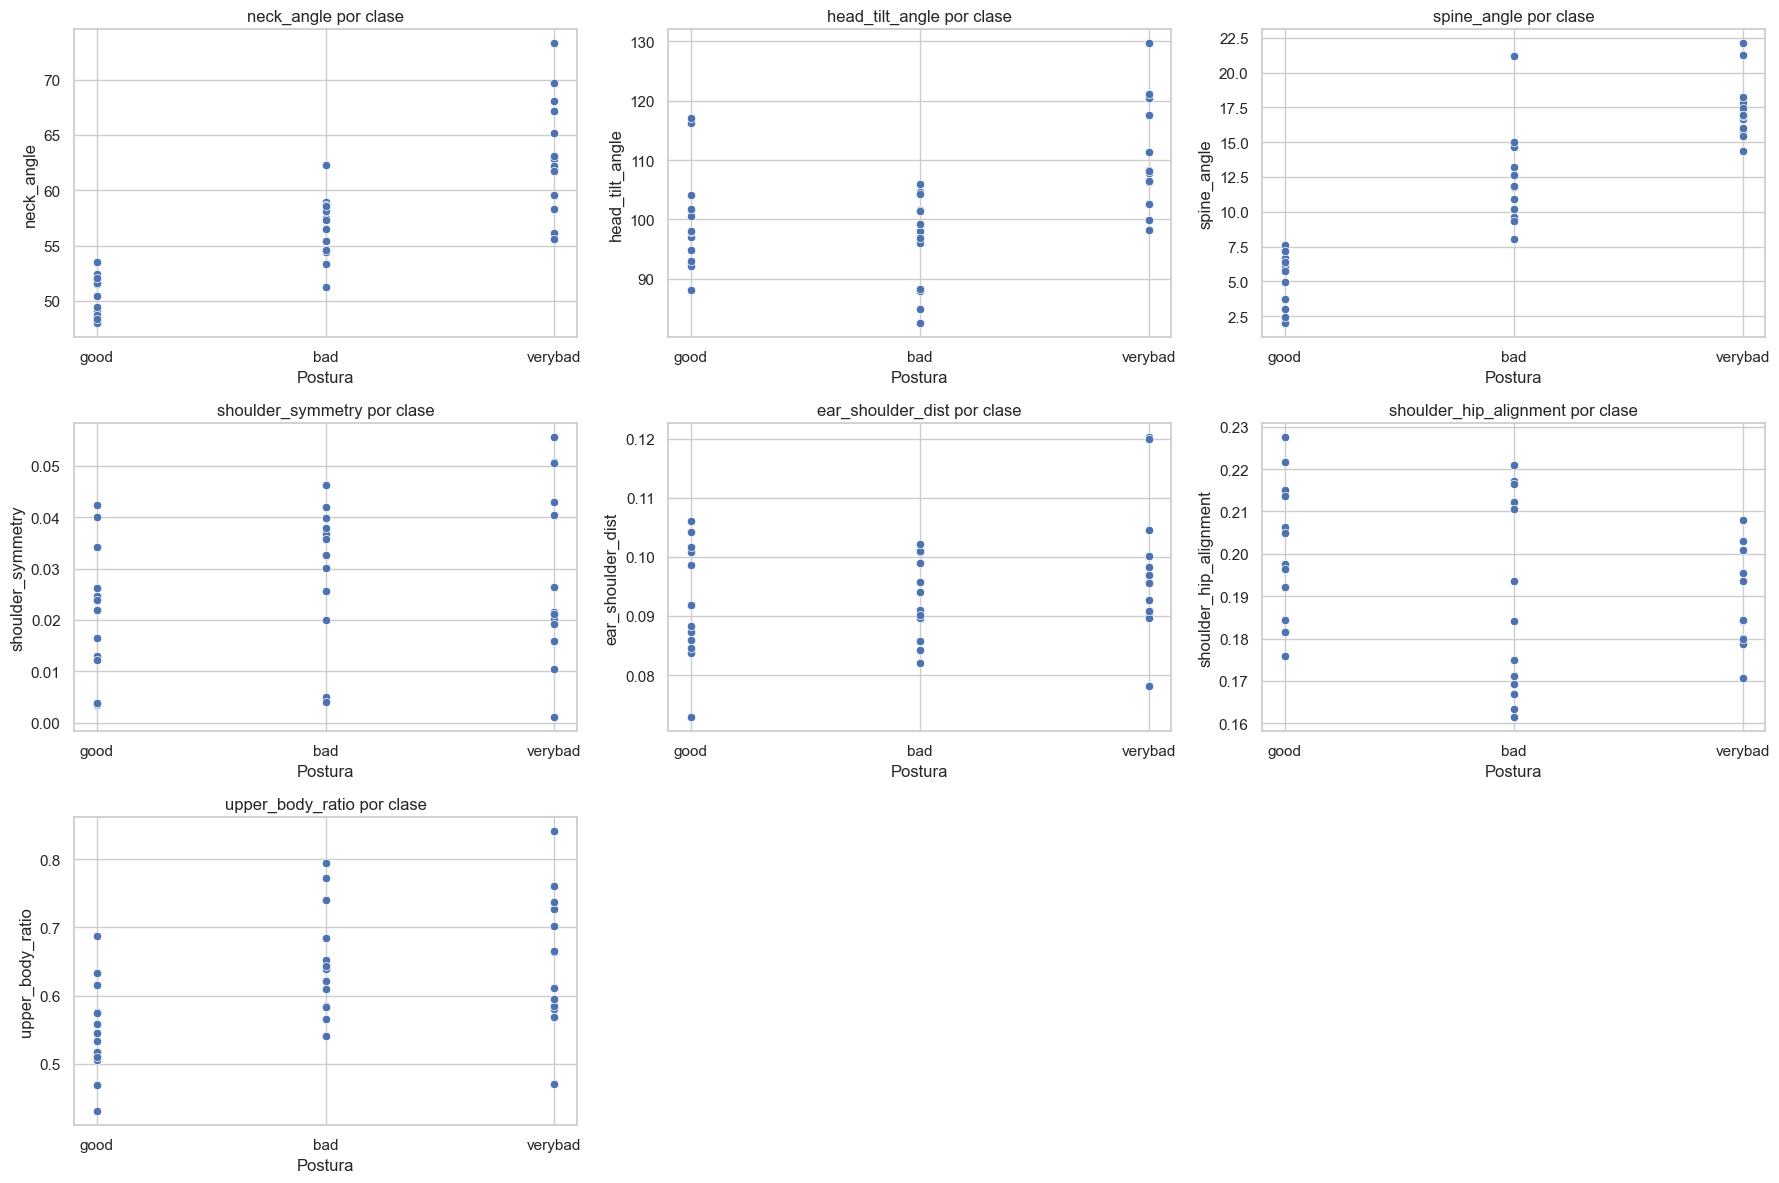

In [5]:
# Cargar el CSV con las features
df = pd.read_csv("posture_features.csv")

# Lista de features numéricas
features = [
    'neck_angle',
    'head_tilt_angle',
    'spine_angle',
    'shoulder_symmetry',
    'ear_shoulder_dist',
    'shoulder_hip_alignment',
    'upper_body_ratio'
]

# Configuración de estilo
sns.set(style="whitegrid")

# Crear subplots (cuadrícula automática)
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axs = axs.flatten()

# Plot de cada feature contra la clase
for i, feature in enumerate(features):
    sns.scatterplot(data=df, x="label", y=feature, ax=axs[i])
    axs[i].set_title(f"{feature} por clase")
    axs[i].set_xlabel("Postura")
    axs[i].set_ylabel(feature)

# Eliminar ejes vacíos si hay menos de 9 plots
for j in range(len(features), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

##### A pesar de tener un par de features con un comportamiento claro, en general hay mucho traslape de estas entre clases, lo que puede complicar la discriminación de estas

##### Y por ultimo en el preprocesado, se hace un reordenamiento para ayuda en el análisis visual de los datos, obteniendo como resultado un archivo csv que consta del nombre de la imagen, el numero de persona, la label de postura y las features extraídas.

##### Una vez tenidas las features, se procede al entrenamiento de los modelos, primero se entrenó al clasificador random forest, el cual terminó siendo el modelo con mejor rendimiento obteniendo un accuracy de 0.8, y además teniendo errores menos distribuidos por decirlo de una manera, el código muestra solo el resultado final, sin embargo se hicieron distintas iteraciones de este modelo con distintas features y se seleccionaron las más relevantes para el código final

              precision    recall  f1-score   support

         bad       0.67      0.67      0.67         3
        good       0.67      0.67      0.67         3
     verybad       1.00      1.00      1.00         4

    accuracy                           0.80        10
   macro avg       0.78      0.78      0.78        10
weighted avg       0.80      0.80      0.80        10



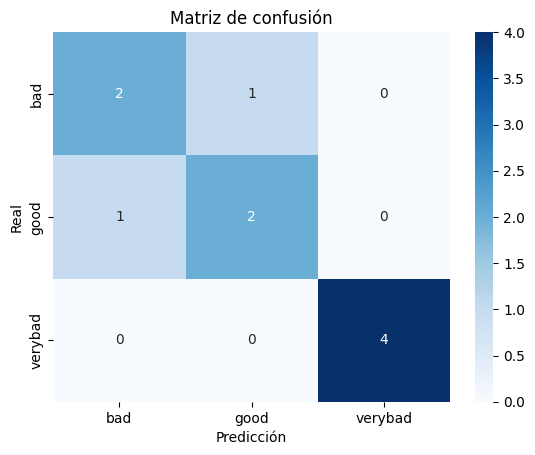

In [3]:
# Cargar el CSV
df = pd.read_csv("posture_features.csv")

features = [
    "neck_angle", "head_tilt_angle", "spine_angle", "shoulder_symmetry",
    "ear_shoulder_dist", "shoulder_hip_alignment", "upper_body_ratio"
]

X = df[features]
y = df["label"]

# Separar en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

# Entrenar modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


##### También se entrenó a un clasificador SVM, el cual obtuvo un accuracy de 0.7, mostrando un buen rendimiento, sin embargo el modelo de random forest estuvo por encima.

              precision    recall  f1-score   support

         bad       0.67      0.67      0.67         3
        good       0.60      1.00      0.75         3
     verybad       1.00      0.50      0.67         4

    accuracy                           0.70        10
   macro avg       0.76      0.72      0.69        10
weighted avg       0.78      0.70      0.69        10



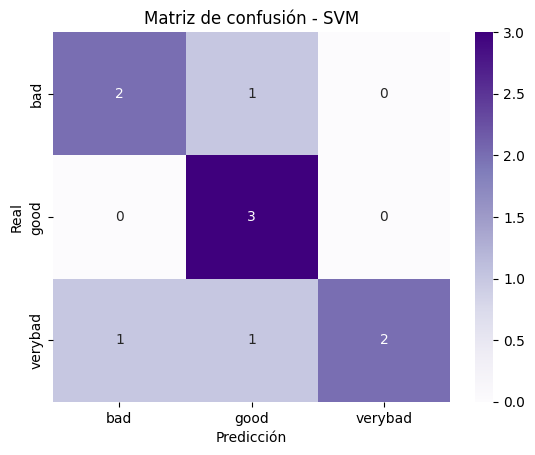

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar SVM
model_svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
model_svm.fit(X_train_scaled, y_train)

# Predicción y evaluación
y_pred = model_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            xticklabels=model_svm.classes_, yticklabels=model_svm.classes_)
plt.title("Matriz de confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


##### Y por ultimo, se entrenó un modelo KNN, el cual tuvo la peor accuracy con 0.6, por lo cual este hubiera quedado totalmente descartado pero sirve para comparar y analizar las diferencias

              precision    recall  f1-score   support

         bad       0.50      0.67      0.57         3
        good       0.60      1.00      0.75         3
     verybad       1.00      0.25      0.40         4

    accuracy                           0.60        10
   macro avg       0.70      0.64      0.57        10
weighted avg       0.73      0.60      0.56        10



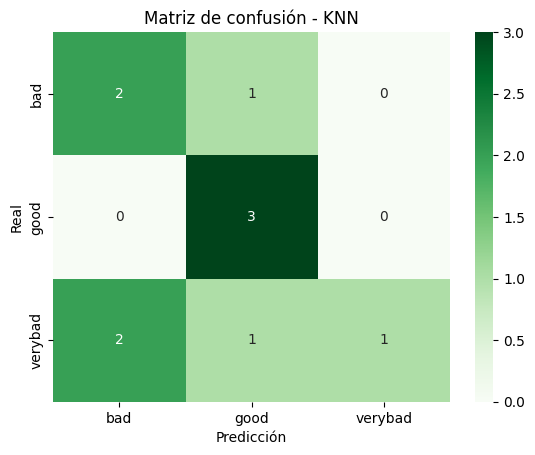

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar KNN
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

# Predicción y evaluación
y_pred = model_knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=model_knn.classes_, yticklabels=model_knn.classes_)
plt.title("Matriz de confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [34]:
import pickle
output_path = "Posture_Model.pkl"

# Guardar el modelo entrenado
with open(output_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Modelo guardado en: {output_path}")


Modelo guardado en: Posture_Model.pkl


##### Al ser el modelo con mejor rendimiento random forest se guardó el modelo de predicción para después usarse en tiempo real.

##### Como complemento, también se hizo un análisis exploratorio del comportamiento de las features en el modelo, se puede observar cómo este se apoya principalmente de los ángulos de el cuello, columna y cabeza, partes del cuerpo que son indicadores muy importantes de la postura evidentemente, pero además de esto también muestra otras cosas curiosas, de inicio, yo pensaba que el shoulder hip alignment tendría más relevancia que las demás features que implementé pero que pensé que no aportarían nada, sin embargo se puede observar que el upper body ratio  y el ear shoulder distance también son relevantes para este, lo que me generó sorpresa

C:\Users\lizar\AppData\Local\Temp\ipykernel_30904\2762110620.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette="viridis")


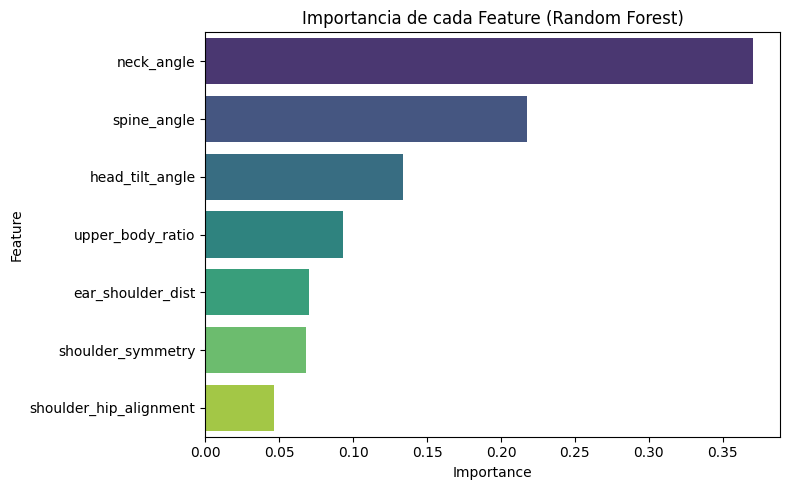

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la importancia de las features
importances = model.feature_importances_
feature_names = X_train.columns

# DataFrame ordenado
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette="viridis")
plt.title("Importancia de cada Feature (Random Forest)")
plt.tight_layout()
plt.show()


##### Y además de eso, también se puede observar que si hay mucho traslape entre las features, sin embargo es clara la fácilidad de discriminación en el top de features que son el angulo del cuello y de la columna, al hacer el análisis exploratorio yo pensé que este traslape generaría más problemas para distinguir entre clases, sin embargo considero que el resultado no fue malo 

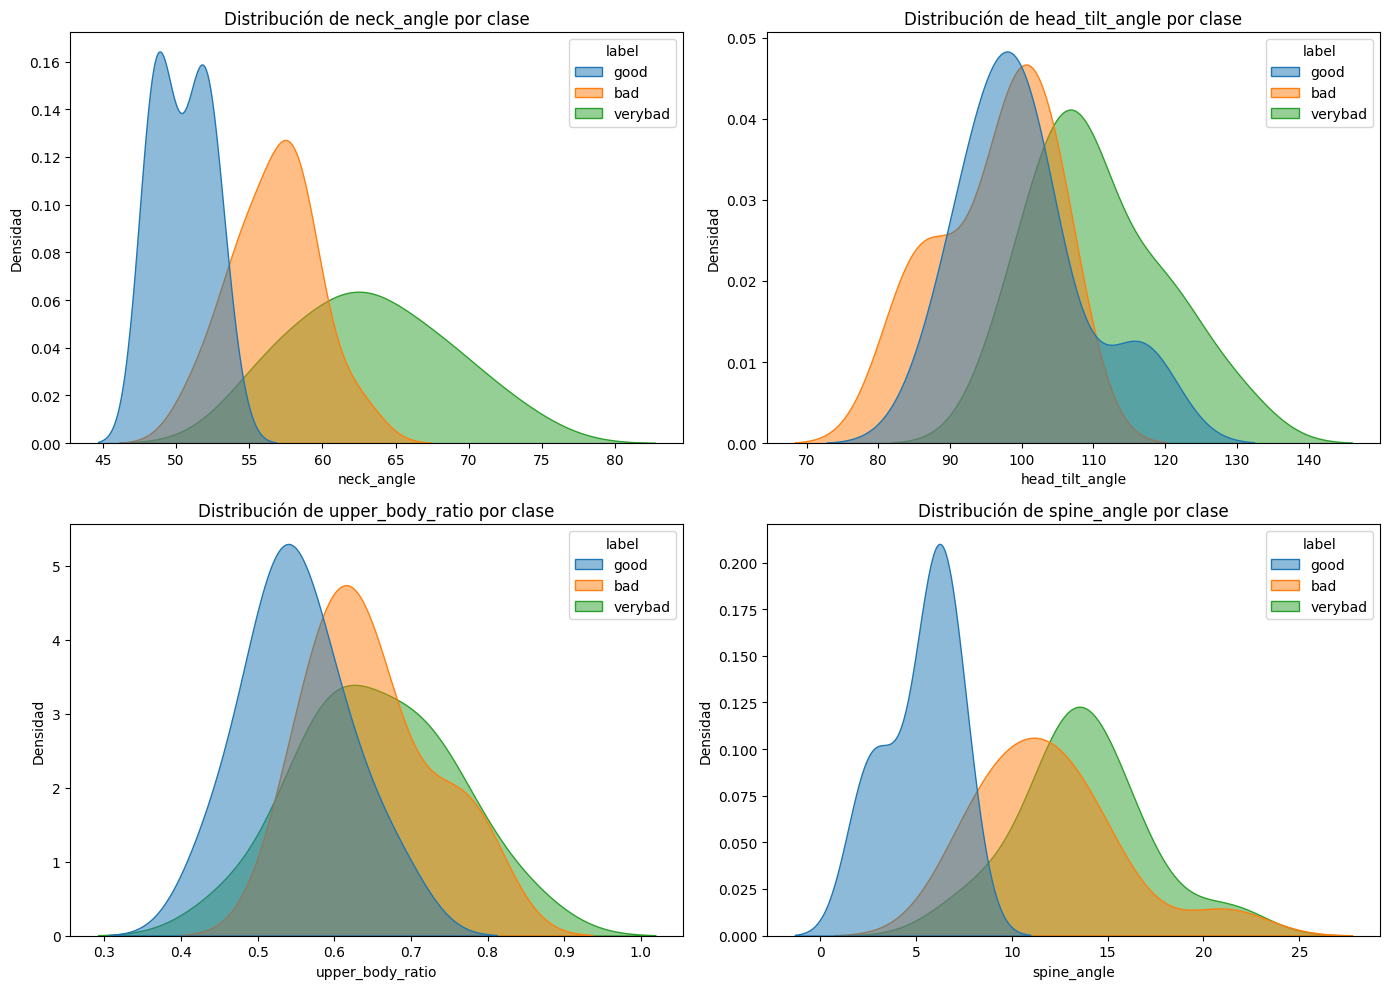

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Features más importantes
top_features = ['neck_angle', 'head_tilt_angle', 'upper_body_ratio', 'spine_angle']

# subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot KDE para cada feature
for ax, feature in zip(axes, top_features):
    sns.kdeplot(data=df, x=feature, hue='label', fill=True, common_norm=False, alpha=0.5, ax=ax)
    ax.set_title(f'Distribución de {feature} por clase')
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()


##### Hasta el momento no se ha mencionado el IMU, y esto es porque durante el recolectado de datos se tuvieron problemas con este y no se pudo conectar a la computadora, después de esto al no tener datos de otras personas y tener menos tiempo, se optó por hacer un sistema convencional en tiempo real en base al angulo.

##### Como nota, las importaciones y funciones ya estaban declaradas antes, pero por finalidad de hacer más sencillas las pruebas dejé todo listo en los bloques

In [ ]:
#Re importar todo para poder probar el puro bloque

from openzen import PyZenManager
import cv2
import time
import numpy as np
import pandas as pd
import mediapipe as mp
import joblib
import winsound
from datetime import datetime

# Inicializar pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)

# Cargar modelo
model = joblib.load("posture_model.pkl")
features_names = ["neck_angle", "head_tilt_angle", "spine_angle", "shoulder_symmetry",
                  "ear_shoulder_dist", "shoulder_hip_alignment", "upper_body_ratio"]

def angle_between(v1, v2):
    unit_v1 = v1 / (np.linalg.norm(v1) + 1e-6)
    unit_v2 = v2 / (np.linalg.norm(v2) + 1e-6)
    dot = np.clip(np.dot(unit_v1, unit_v2), -1.0, 1.0)
    return np.degrees(np.arccos(dot))

def extract_features_from_image(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)

    if not results.pose_landmarks:
        return None

    lm = results.pose_landmarks.landmark
    def get_xy(index): return np.array([lm[index].x, lm[index].y])

    try:
        left_shoulder = get_xy(mp_pose.PoseLandmark.LEFT_SHOULDER.value)
        right_shoulder = get_xy(mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
        left_hip = get_xy(mp_pose.PoseLandmark.LEFT_HIP.value)
        right_hip = get_xy(mp_pose.PoseLandmark.RIGHT_HIP.value)
        left_ear = get_xy(mp_pose.PoseLandmark.LEFT_EAR.value)
        right_ear = get_xy(mp_pose.PoseLandmark.RIGHT_EAR.value)
        nose = get_xy(mp_pose.PoseLandmark.NOSE.value)

        shoulder_mid = (left_shoulder + right_shoulder) / 2
        hip_mid = (left_hip + right_hip) / 2
        ear_mid = (left_ear + right_ear) / 2

        neck_vec = nose - shoulder_mid
        vertical = np.array([0, -1])
        spine_vec = shoulder_mid - hip_mid
        head_vec = nose - ear_mid

        return {
            "neck_angle": angle_between(neck_vec, vertical),
            "head_tilt_angle": angle_between(head_vec, vertical),
            "spine_angle": angle_between(spine_vec, vertical),
            "shoulder_symmetry": abs(left_shoulder[1] - right_shoulder[1]),
            "ear_shoulder_dist": np.linalg.norm(ear_mid - shoulder_mid),
            "shoulder_hip_alignment": abs(shoulder_mid[1] - hip_mid[1]),
            "upper_body_ratio": np.linalg.norm(neck_vec) / (np.linalg.norm(spine_vec) + 1e-6),
        }
    except:
        return None

def beep_alert():
    winsound.Beep(1000, 300)  # frecuencia, duración (ms)

manager = PyZenManager()
imu = None
offset_pitch = 0

def init_imu():
    global imu
    res, sensor = manager.obtain_sensor()
    if res != 0:
        raise Exception("No se pudo conectar al IMU.")
    sensor.set_int_property("enable_sensor_fusion", 1)
    imu = sensor

def get_pitch():
    global imu, offset_pitch
    events = manager.poll_next_event()
    if events.sensor_event:
        q = events.sensor_event.orientation
        pitch = np.degrees(np.arcsin(2 * (q.w * q.y - q.z * q.x))) - offset_pitch
        return pitch
    return None

# === Loop principal ===
init_imu()
alert_flag = False

cap = cv2.VideoCapture(0)

print("Sistema de monitoreo de postura iniciado).")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("No se pudo acceder a la cámara.")
            break

        features = extract_features_from_image(frame)

        imu_pitch = get_pitch()
        print(f"IMU Pitch: {imu_pitch:.2f}" if imu_pitch else "No IMU reading")

        if features:
            X = np.array([list(features.values())])
            prediction = model.predict(X)[0]
            print(f"Postura detectada: {prediction}")

            if prediction != "good" or (imu_pitch and abs(imu_pitch) > 15):
                if not bad_posture_flag:
                    print("Mala postura detectada. Beep.")
                    beep_alert()
                    alert_flag = True
            else:
                if bad_posture_flag:
                    print("Postura corregida. Offset reset.")
                    alert_flag = False
                    offset_pitch += imu_pitch  # Offset para evitar acumulación
        else:
            print("No se pudieron extraer landmarks.")

        time.sleep(30)

except KeyboardInterrupt:
    print("Finalizado por usuario.")

finally:
    cap.release()
    manager.close()
    cv2.destroyAllWindows()


##### El bloque de arriba es la función principal del sistema en tiempo real, este consta de un par de elementos principales, el primero siendo la extracción de features, esta función queda predefinida para seguir exactamente el mismo proceso que en el entrenamiento, pero ahora implementado en el sistema de tiempo real, para esto, se usó la función de videocapture de cv2, en la cual conecté a mi cámara 0 que dejé preparado en vertical para las pruebas, para el caso del IMU, se determinó un límite de 15 grados para considerar una mala postura, para esto, el IMU se insertó en un gorro.

In [ ]:
#Re importar todo para poder probar el puro bloque
#Versión solo con camara lateral

import cv2
import time
import numpy as np
import pandas as pd
import mediapipe as mp
import joblib
import winsound
from datetime import datetime

# Inicializar Mediapipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

# Cargar modelo
model = joblib.load("Posture_Model.pkl")
features_names = ["neck_angle", "head_tilt_angle", "spine_angle", "shoulder_symmetry",
                  "ear_shoulder_dist", "shoulder_hip_alignment", "upper_body_ratio"]


def angle_between(v1, v2):
    unit_v1 = v1 / (np.linalg.norm(v1) + 1e-6)
    unit_v2 = v2 / (np.linalg.norm(v2) + 1e-6)
    dot = np.clip(np.dot(unit_v1, unit_v2), -1.0, 1.0)
    return np.degrees(np.arccos(dot))

def extract_features(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image_rgb)
    if not results.pose_landmarks:
        return None

    lm = results.pose_landmarks.landmark
    def get_xy(index):
        return np.array([lm[index].x, lm[index].y])

    try:
        left_shoulder = get_xy(mp_pose.PoseLandmark.LEFT_SHOULDER.value)
        right_shoulder = get_xy(mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
        left_hip = get_xy(mp_pose.PoseLandmark.LEFT_HIP.value)
        right_hip = get_xy(mp_pose.PoseLandmark.RIGHT_HIP.value)
        left_ear = get_xy(mp_pose.PoseLandmark.LEFT_EAR.value)
        right_ear = get_xy(mp_pose.PoseLandmark.RIGHT_EAR.value)
        nose = get_xy(mp_pose.PoseLandmark.NOSE.value)

        shoulder_mid = (left_shoulder + right_shoulder) / 2
        hip_mid = (left_hip + right_hip) / 2
        ear_mid = (left_ear + right_ear) / 2

        neck_vec = nose - shoulder_mid
        vertical = np.array([0, -1])
        neck_angle = angle_between(neck_vec, vertical)

        head_vec = nose - ear_mid
        head_tilt_angle = angle_between(head_vec, vertical)

        spine_vec = shoulder_mid - hip_mid
        spine_angle = angle_between(spine_vec, vertical)

        shoulder_symmetry = abs(left_shoulder[1] - right_shoulder[1])
        ear_shoulder_dist = np.linalg.norm(ear_mid - shoulder_mid)
        shoulder_hip_alignment = abs(shoulder_mid[1] - hip_mid[1])
        neck_length = np.linalg.norm(neck_vec)
        upper_body_ratio = neck_length / (np.linalg.norm(spine_vec) + 1e-6)

        return [neck_angle, head_tilt_angle, spine_angle, shoulder_symmetry,
                ear_shoulder_dist, shoulder_hip_alignment, upper_body_ratio]

    except:
        return None

def beep_alert():
    winsound.Beep(1000, 300)  # frecuencia, duración

# === Loop principal ===
alert_flag = False

cap = cv2.VideoCapture(0)

print("Sistema de monitoreo de postura iniciado).")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("No se pudo capturar imagen.")
            continue

        features = extract_features(frame)

        if features:
            df = pd.DataFrame([features], columns=features_names)
            prediction = model.predict(df)[0]
            print(f"Postura detectada: {prediction}")

            if prediction != "good":
                if not alert_flag:
                    beep_alert()
                    print("Alerta de mala postura")
                    alert_flag = True
            else:
                if alert_flag:
                    print("Postura corregida. Reiniciando flag.")
                alert_flag = False
        else:
            print("No se detectaron landmarks.")

        # 5 segundos para pruebas
        time.sleep(5)

except KeyboardInterrupt:
    print("\nInterrupción manual. Cerrando sistema...")

cap.release()
cv2.destroyAllWindows()



Sistema de monitoreo de postura iniciado).
Postura detectada: good

Interrupción manual. Cerrando sistema...


##### Por ultimo, el día en el que hice el reporte empecé a tener problemas con la conexión de mi IMU y no lo pude hacer funcionar, sin embargo preparé un script el cual usa solo el modelo y la cámara, este sistema si funcionó sin problema y se utilizó durante un par de horas para mantener un monitoreo constante, obteniendo resultados muy buenos y un sistema muy cómodo de utilizar
